# P5: Anticipating a Tennis Swing from the Ball Approach

This notebook builds a small real-video world model from 11 handheld tennis clips
(5 forehand, 6 backhand). The headline changed after a better diagnostic: the
swing side is highly predictable from the **opening frames** where the ball is
approaching and the player is preparing.

The pipeline has two parts:
1. **Anticipation:** test whether a linear probe can decode forehand/right versus
   backhand/left from held-out clips.
2. **Dreaming:** train a latent GRU world model, seed it with opening frames, roll
   forward, and retrieve nearest real frames to watch the predicted continuation.

## 1. Setup

The implementation lives in `run_tennis_wm.py` so the notebook and command-line
reproduction use the same code path. Run the full project from the repository root
with:

```bash
python p5_tennis_world_model/run_tennis_wm.py
```

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'p5_tennis_world_model':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'p5_tennis_world_model'))

from IPython.display import Image, display

from run_tennis_wm import RESULTS, load_all, anticipation, rollout_vs_persistence, dream

## 2. Load Data and Latents

Each frame is embedded with frozen DINOv2 ViT-S/14 using the global CLS token.
Corrupt frames are dropped, and each clip is mirrored horizontally. The mirror
augmentation doubles the data and swaps the left/right side label.

In [2]:
data = load_all()
print(f'{len(data)} clips loaded')
print(next(iter(data.items()))[0], next(iter(data.items()))[1]['emb'].shape)

Using cache found in /Users/silv/.cache/torch/hub/facebookresearch_dinov2_main
/Users/silv/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/silv/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/silv/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


11 clips loaded
backhand_01.MOV (46, 384)


## 3. Anticipation Probe

The earlier full-clip question was the wrong test for anticipation. A swing should
be predicted before it happens, so the relevant signal is in the first few frames:
ball approach plus preparation pose.

We run leave-one-clip-out logistic regression in four setups: full clip versus
opening frames, each with and without flip augmentation.

full / no flip    : 0.616
full / + flip     : 0.582
opening / no flip : 0.943
opening / + flip  : 0.989
figure: /Users/silv/Documents/Programming/vla-wm/results/p5_anticipation.png


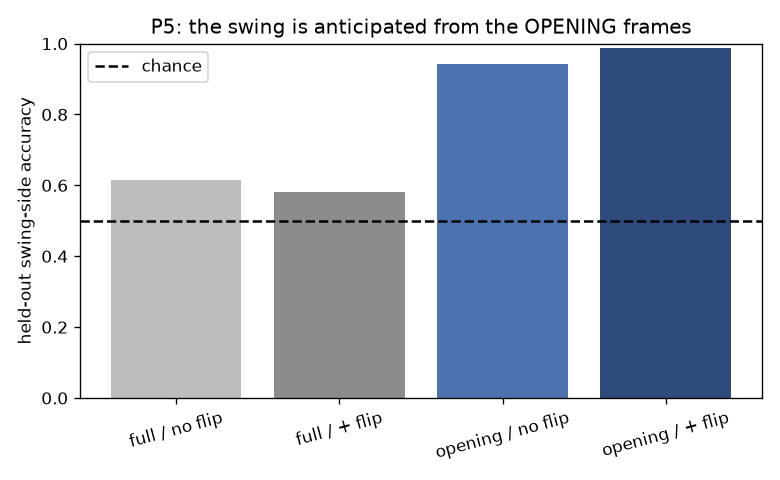

In [3]:
ant = anticipation(data)
for k, v in ant.items():
    print(f'{k:18s}: {v:.3f}')
print('figure:', RESULTS / 'p5_anticipation.png')
display(Image(filename=RESULTS / 'p5_anticipation.png'))

**Result:** held-out side accuracy is about `0.94` from opening frames and `0.99`
with flip augmentation, versus about `0.6` over the full clip. The practical
interpretation is strong: the model can anticipate which swing is coming from the
incoming ball/preparation phase, but averaging over later swing frames dilutes the
signal.

Caveat: all clips are handheld and from one session, so some of this signal may be
camera/framing as well as ball and body pose.

## 4. Latent World Model

The dynamics model is a small GRU over standardized DINOv2 latents. It is warmed
up on a short context and then rolled out freely. We compare against persistence,
which predicts no change and is a strong baseline because adjacent video frames
move only a little.

world model: [np.float32(0.025), np.float32(0.039), np.float32(0.047), np.float32(0.051), np.float32(0.056), np.float32(0.059), np.float32(0.06), np.float32(0.062), np.float32(0.063), np.float32(0.066), np.float32(0.067), np.float32(0.069)]
persistence: [np.float32(0.027), np.float32(0.046), np.float32(0.06), np.float32(0.069), np.float32(0.074), np.float32(0.076), np.float32(0.077), np.float32(0.079), np.float32(0.082), np.float32(0.087), np.float32(0.091), np.float32(0.096)]
horizon 12: world model=0.069 persistence=0.096
figure: /Users/silv/Documents/Programming/vla-wm/results/p5_rollout_error.png


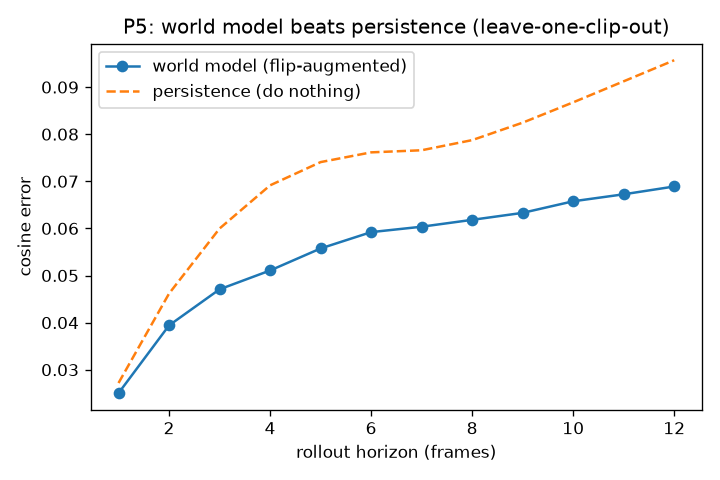

In [4]:
e_wm, e_pe = rollout_vs_persistence(data)
print('world model:', [round(x, 3) for x in e_wm])
print('persistence:', [round(x, 3) for x in e_pe])
print('horizon 12: world model=%.3f persistence=%.3f' % (e_wm[-1], e_pe[-1]))
print('figure:', RESULTS / 'p5_rollout_error.png')
display(Image(filename=RESULTS / 'p5_rollout_error.png'))

**Result:** the flip-augmented world model beats persistence through the rollout.
The model is not just freezing the current frame; it has learned a useful latent
motion prior from the small dataset.

## 5. Dream a Swing Continuation

A predicted latent sequence is not directly watchable. To visualize it without
training a pixel decoder, each predicted latent is mapped to the nearest frame in
the real frame bank. This produces a qualitative dream of the continuation seeded
from opening frames.

strip: /Users/silv/Documents/Programming/vla-wm/results/p5_dream.png


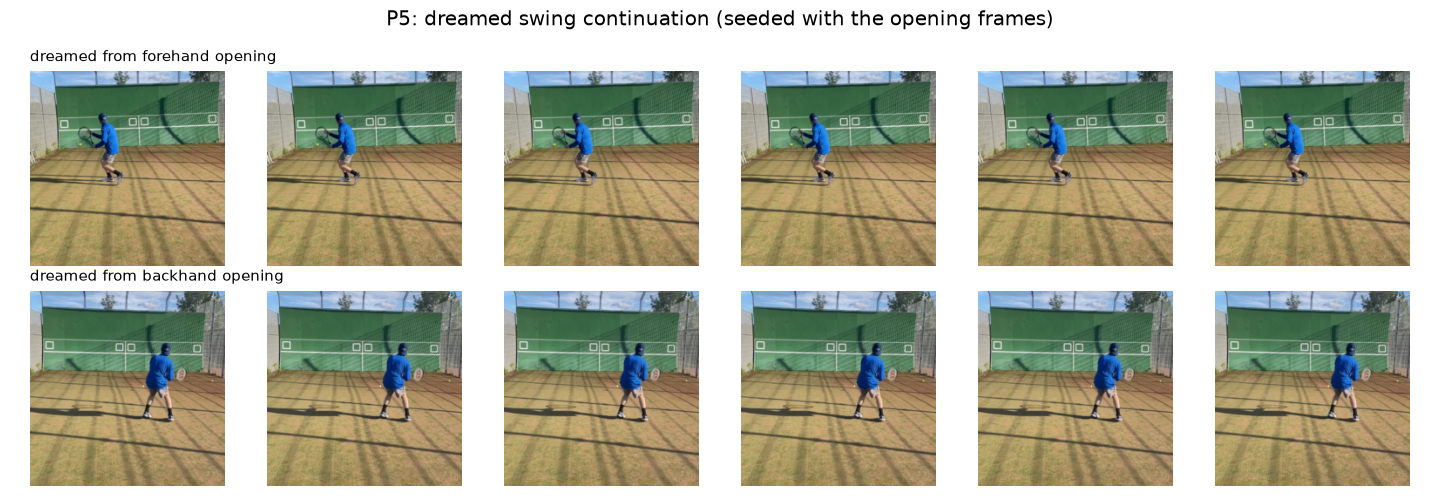

forehand gif: /Users/silv/Documents/Programming/vla-wm/results/p5_dream_forehand.gif


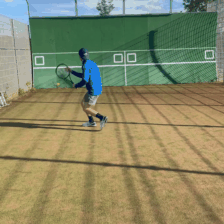

backhand gif: /Users/silv/Documents/Programming/vla-wm/results/p5_dream_backhand.gif


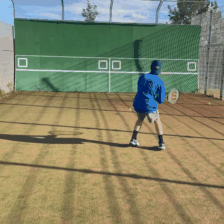

In [5]:
dream(data)
print('strip:', RESULTS / 'p5_dream.png')
display(Image(filename=RESULTS / 'p5_dream.png'))
print('forehand gif:', RESULTS / 'p5_dream_forehand.gif')
display(Image(filename=RESULTS / 'p5_dream_forehand.gif'))
print('backhand gif:', RESULTS / 'p5_dream_backhand.gif')
display(Image(filename=RESULTS / 'p5_dream_backhand.gif'))

## 6. What P5 Shows

P5 is now a clearer anticipation project:

- Opening frames contain a strong held-out signal for swing side.
- Flip augmentation reinforces the left/right rule.
- The latent GRU beats persistence, so it learns swing dynamics rather than only
  copying the last frame.
- The dream demo turns latent rollouts into watchable nearest-neighbor sequences.

The next useful upgrade is cleaner multi-session data with controlled framing and
an explicit ball/pose state, so the anticipation signal can be separated from
camera setup.